In [4]:
import pandas as pd

csv_path = "./data/dataset.csv"
df= pd.read_csv(csv_path, encoding="utf-8")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
# Pick the columns that are useful for game music decisions
cols_of_interest = [
    "track_name",
    "artists",
    "track_genre",
    "tempo",
    "energy",
    "valence",
    "danceability",
    "loudness",
    "popularity"
]

music_df = df[cols_of_interest].copy()

music_df.head()

,track_name,artists,track_genre,tempo,energy,valence,danceability,loudness,popularity
0,Comedy,Gen Hoshino,acoustic,87.917,0.4610,0.715,0.676,-6.746,73
1,Ghost - Acoustic,Ben Woodward,acoustic,77.489,0.1660,0.267,0.420,-17.235,55
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,76.332,0.3590,0.120,0.438,-9.734,57
3,Can't Help Falling In Love,Kina Grannis,acoustic,181.740,0.0596,0.143,0.266,-18.515,71
4,Hold On,Chord Overstreet,acoustic,119.949,0.4430,0.167,0.618,-9.681,82


In [7]:
# Check for missing values in these key columns
music_df.isna().sum()

# Basic stats for numeric features
music_df[["tempo", "energy", "valence", "danceability", "loudness", "popularity"]].describe()

# See the top 10 most common genres
music_df["track_genre"].value_counts().head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

In [8]:
# Define tempo categories (you can adjust thresholds)
def tempo_category(bpm):
    if bpm < 90:
        return "slow"
    elif bpm < 120:
        return "medium"
    else:
        return "fast"

music_df["tempo_cat"] = music_df["tempo"].apply(tempo_category)

# Define energy categories
def energy_category(e):
    if e < 0.4:
        return "low"
    elif e < 0.7:
        return "medium"
    else:
        return "high"

music_df["energy_cat"] = music_df["energy"].apply(energy_category)

# Quick counts
music_df["tempo_cat"].value_counts()
music_df["energy_cat"].value_counts()

energy_cat
high      54649
medium    38133
low       21218
Name: count, dtype: int64

In [9]:
# Top 10 genres
top_genres = music_df["track_genre"].value_counts().head(10)
print(top_genres)

# Average tempo per top genre
avg_tempo_by_genre = (
    music_df[music_df["track_genre"].isin(top_genres.index)]
    .groupby("track_genre")["tempo"]
    .mean()
    .sort_values(ascending=False)
)
avg_tempo_by_genre

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


track_genre
black-metal    128.601515
bluegrass      126.578805
alt-rock       124.634404
anime          123.529616
alternative    122.232394
brazil         121.935644
afrobeat       119.213337
acoustic       119.010624
blues          116.568352
ambient        111.113129
Name: tempo, dtype: float64

In [10]:
tempo_energy_counts = (
    music_df
    .groupby(["tempo_cat", "energy_cat"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

tempo_energy_counts

,tempo_cat,energy_cat,count
0,fast,high,33751
2,fast,medium,18773
3,medium,high,17029
5,medium,medium,13186
1,fast,low,8172
4,medium,low,6701
7,slow,low,6345
8,slow,medium,6174
6,slow,high,3869


In [11]:
# Quick summary of mood features
music_df[["valence", "danceability"]].describe()

# Simple categorization of valence
def valence_category(v):
    if v < 0.3:
        return "sad/dark"
    elif v < 0.6:
        return "neutral"
    else:
        return "happy/bright"

music_df["valence_cat"] = music_df["valence"].apply(valence_category)

valence_counts = music_df["valence_cat"].value_counts()
valence_counts

valence_cat
neutral         41534
happy/bright    38789
sad/dark        33677
Name: count, dtype: int64

In [12]:
def assign_game_context(row):
    tempo_cat = row["tempo_cat"]
    energy_cat = row["energy_cat"]
    valence_cat = row["valence_cat"]

    # Competitive / intense matches
    if tempo_cat == "fast" and energy_cat == "high" and valence_cat in ["neutral", "happy/bright"]:
        return "competitive_match"

    # Victory / celebration
    if tempo_cat in ["medium", "fast"] and energy_cat == "high" and valence_cat == "happy/bright":
        return "victory_celebration"

    # Training / practice
    if tempo_cat == "medium" and energy_cat == "medium" and valence_cat in ["neutral", "happy/bright"]:
        return "training_mode"

    # Menus / lobby
    if tempo_cat in ["slow", "medium"] and energy_cat in ["low", "medium"] and valence_cat in ["neutral", "happy/bright"]:
        return "menu_lobby"

    # Fallback
    return "unassigned"

music_df["game_context"] = music_df.apply(assign_game_context, axis=1)

# See how many tracks are in each context
context_counts = music_df["game_context"].value_counts()
context_counts

game_context
unassigned             60278
competitive_match      25373
menu_lobby             10386
training_mode          10227
victory_celebration     7736
Name: count, dtype: int64

In [13]:
music_df[music_df["game_context"] == "menu_lobby"].head(10)[
    ["track_name", "artists", "track_genre", "tempo", "energy", "valence", "game_context"]
]

,track_name,artists,track_genre,tempo,energy,valence,game_context
0,Comedy,Gen Hoshino,acoustic,87.917,0.4610,0.715,menu_lobby
10,Give Me Your Forever,Zack Tabudlo,acoustic,99.905,0.3630,0.301,menu_lobby
16,ily (i love you baby),Andrew Foy;Renee Foy,acoustic,110.154,0.1120,0.414,menu_lobby
17,At My Worst,Andrew Foy;Renee Foy,acoustic,91.803,0.0841,0.609,menu_lobby
19,Photograph,Boyce Avenue;Bea Miller,acoustic,107.946,0.3200,0.322,menu_lobby
21,Demons,Boyce Avenue;Jennel Garcia,acoustic,90.032,0.3510,0.569,menu_lobby
38,This Time Tomorrow,Brandi Carlile,acoustic,91.626,0.3260,0.414,menu_lobby
50,Trampoline - Acoustic,Highland Peak,acoustic,107.893,0.2000,0.308,menu_lobby
53,A Drop in the Ocean,Ron Pope,acoustic,73.139,0.3930,0.564,menu_lobby
57,Sleepwalking in the Rain,Chord Overstreet,acoustic,80.075,0.3810,0.502,menu_lobby


In [14]:
# 1. Total tracks and distinct genres
num_tracks = len(music_df)
num_genres = music_df["track_genre"].nunique()

print("Total tracks:", num_tracks)
print("Number of distinct genres:", num_genres)

# 2. How many tracks per game context
context_counts = music_df["game_context"].value_counts()
print(context_counts)

# 3. Average tempo and energy overall
avg_tempo = music_df["tempo"].mean()
avg_energy = music_df["energy"].mean()

print("Average tempo (BPM):", round(avg_tempo, 2))
print("Average energy:", round(avg_energy, 2))

Total tracks: 114000
Number of distinct genres: 114
game_context
unassigned             60278
competitive_match      25373
menu_lobby             10386
training_mode          10227
victory_celebration     7736
Name: count, dtype: int64
Average tempo (BPM): 122.15
Average energy: 0.64


In [15]:
competitive = music_df[music_df["game_context"] == "competitive_match"]
print("Competitive tracks:", len(competitive))
print("Avg tempo (competitive):", round(competitive["tempo"].mean(), 2))
print("Avg energy (competitive):", round(competitive["energy"].mean(), 2))

Competitive tracks: 25373
Avg tempo (competitive): 145.4
Avg energy (competitive): 0.86


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

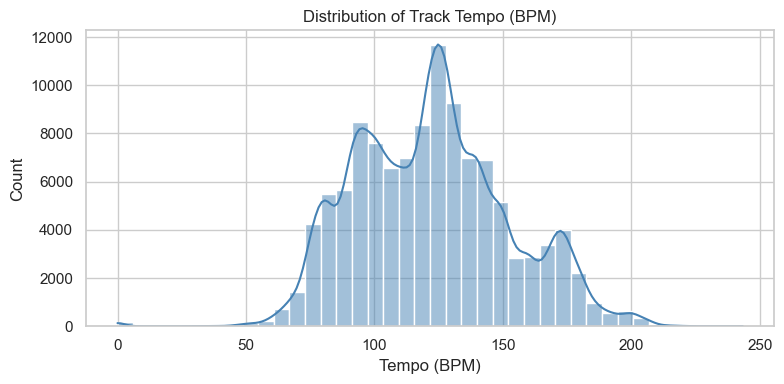

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(music_df["tempo"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Track Tempo (BPM)")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

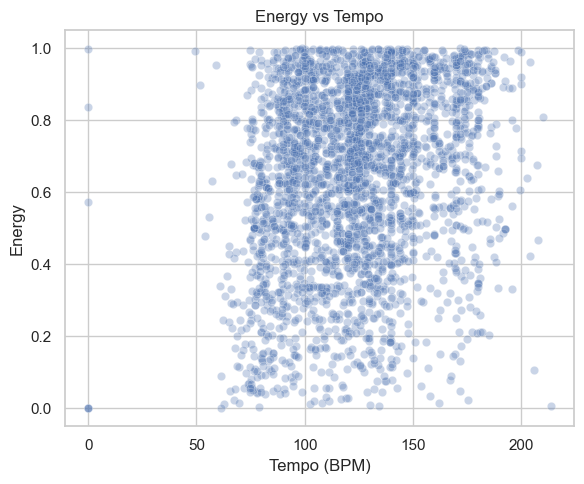

In [18]:
sample = music_df.sample(min(3000, len(music_df)), random_state=42)

plt.figure(figsize=(6, 5))
sns.scatterplot(data=sample, x="tempo", y="energy", alpha=0.3)
plt.title("Energy vs Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

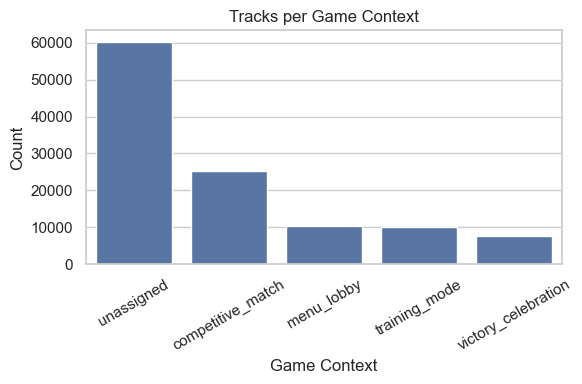

In [19]:
plt.figure(figsize=(6, 4))
order = music_df["game_context"].value_counts().index
sns.countplot(data=music_df, x="game_context", order=order)
plt.title("Tracks per Game Context")
plt.xlabel("Game Context")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

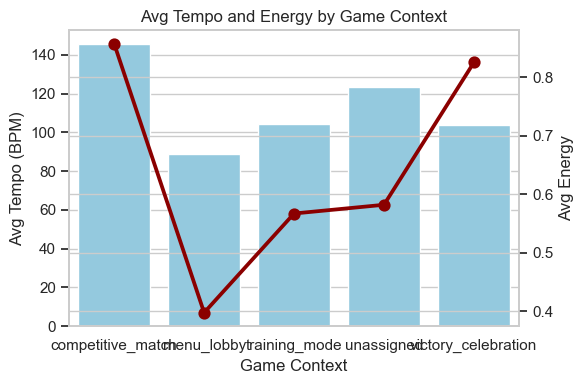

In [20]:
agg = music_df.groupby("game_context")[["tempo", "energy"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

sns.barplot(data=agg, x="game_context", y="tempo", ax=ax1, color="skyblue")
sns.pointplot(data=agg, x="game_context", y="energy", ax=ax2, color="darkred")

ax1.set_xlabel("Game Context")
ax1.set_ylabel("Avg Tempo (BPM)")
ax2.set_ylabel("Avg Energy")
plt.title("Avg Tempo and Energy by Game Context")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()